<a href="https://colab.research.google.com/github/priyanshu-tyagi-py/world_suicide_analysis01/blob/main/World_Suicide_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# World Suicide Rate Analysis (1985–2016)

This project explores global suicide trends using demographic, economic, and geographic variables. The analysis includes exploratory data analysis (EDA), statistical testing, and predictive modeling to understand patterns in suicide rates across countries and over time.

In [2]:
# ======================================
# Libraries and Environment Setup
# ======================================
import kagglehub
path = kagglehub.dataset_download("russellyates88/suicide-rates-overview-1985-to-2016")

100%|██████████| 397k/397k [00:00<00:00, 72.9MB/s]

Extracting files...


In [3]:
print(path)

/root/.cache/kagglehub/datasets/russellyates88/suicide-rates-overview-1985-to-2016/versions/1


In [4]:
import os

os.listdir(path)

['master.csv']

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway

# Plot styling
sns.set_theme(style="whitegrid")

plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

In [6]:
# ======================================
# Load Dataset
# ======================================

df = pd.read_csv(path + "/master.csv")

df.head()

,country,year,sex,age,suicides_no,population,suicides/100k pop,country-year,HDI for year,gdp_for_year ($),gdp_per_capita ($),generation
0,Albania,1987,male,15-24 years,21,312900,6.71,Albania1987,NaN,"2,156,624,900",796,Generation X
1,Albania,1987,male,35-54 years,16,308000,5.19,Albania1987,NaN,"2,156,624,900",796,Silent
2,Albania,1987,female,15-24 years,14,289700,4.83,Albania1987,NaN,"2,156,624,900",796,Generation X
3,Albania,1987,male,75+ years,1,21800,4.59,Albania1987,NaN,"2,156,624,900",796,G.I. Generation
4,Albania,1987,male,25-34 years,9,274300,3.28,Albania1987,NaN,"2,156,624,900",796,Boomers


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27820 entries, 0 to 27819
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country             27820 non-null  object 
 1   year                27820 non-null  int64  
 2   sex                 27820 non-null  object 
 3   age                 27820 non-null  object 
 4   suicides_no         27820 non-null  int64  
 5   population          27820 non-null  int64  
 6   suicides/100k pop   27820 non-null  float64
 7   country-year        27820 non-null  object 
 8   HDI for year        8364 non-null   float64
 9    gdp_for_year ($)   27820 non-null  object 
 10  gdp_per_capita ($)  27820 non-null  int64  
 11  generation          27820 non-null  object 
dtypes: float64(2), int64(4), object(6)
memory usage: 2.5+ MB


In [8]:
df.describe()

,year,suicides_no,population,suicides/100k pop,HDI for year,gdp_per_capita ($)
count,27820.000000,27820.000000,2.782000e+04,27820.000000,8364.000000,27820.000000
mean,2001.258375,242.574407,1.844794e+06,12.816097,0.776601,16866.464414
std,8.469055,902.047917,3.911779e+06,18.961511,0.093367,18887.576472
min,1985.000000,0.000000,2.780000e+02,0.000000,0.483000,251.000000
25%,1995.000000,3.000000,9.749850e+04,0.920000,0.713000,3447.000000
50%,2002.000000,25.000000,4.301500e+05,5.990000,0.779000,9372.000000
75%,2008.000000,131.000000,1.486143e+06,16.620000,0.855000,24874.000000
max,2016.000000,22338.000000,4.380521e+07,224.970000,0.944000,126352.000000


In [9]:
df.isnull().sum()

,0
country,0
year,0
sex,0
age,0
suicides_no,0
population,0
suicides/100k pop,0
country-year,0
HDI for year,19456
gdp_for_year ($),0


In [10]:
df['HDI for year'].count()

np.int64(8364)

In [11]:
df['HDI for year'].isnull().mean() * 100

np.float64(69.93529834651329)

In [12]:
df = df.drop(columns=['HDI for year'], errors='ignore')

The column **'HDI for year'** contains approximately **70% missing values**. Since more
than half of the data is missing, the column was removed from the dataset to maintain data quality. In general, columns with more than 50% missing values are often dropped unless they are critical to the analysis.


In [13]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
27815,False
27816,False
27817,False
27818,False


In [14]:
df.columns = df.columns.str.strip()

In [15]:
df = df.rename(columns={
    'suicides/100k pop': 'suicides_per_100k',
    'gdp_for_year ($)': 'gdp_for_year',
    'gdp_per_capita ($)': 'gdp_per_capita',
    'country-year': 'country_year'
})

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27820 entries, 0 to 27819
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country            27820 non-null  object 
 1   year               27820 non-null  int64  
 2   sex                27820 non-null  object 
 3   age                27820 non-null  object 
 4   suicides_no        27820 non-null  int64  
 5   population         27820 non-null  int64  
 6   suicides_per_100k  27820 non-null  float64
 7   country_year       27820 non-null  object 
 8   gdp_for_year       27820 non-null  object 
 9   gdp_per_capita     27820 non-null  int64  
 10  generation         27820 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 2.3+ MB


In [17]:
df.dtypes

,0
country,object
year,int64
sex,object
age,object
suicides_no,int64
population,int64
suicides_per_100k,float64
country_year,object
gdp_for_year,object
gdp_per_capita,int64


In [18]:
df['gdp_for_year'] = df['gdp_for_year'].str.replace(',', '').astype(int)

In [19]:
df.dtypes

,0
country,object
year,int64
sex,object
age,object
suicides_no,int64
population,int64
suicides_per_100k,float64
country_year,object
gdp_for_year,int64
gdp_per_capita,int64


**Exploratory Data Analysis (EDA)**

In this section, we explore the dataset to understand patterns, relationships, and trends in suicide rates across different demographics and economic indicators.

The objective of EDA is to:
- Identify patterns and trends in the data
- Compare suicide rates across gender, age groups, and countries
- Examine relationships between suicide rates and economic factors
- Detect correlations among numerical variables

In [20]:
df['suicides_no'].sum()

np.int64(6748420)

In [21]:
df['suicides_per_100k'].mean()

np.float64(12.816097411933864)

In [22]:
df['country'].nunique()

101

In [23]:
df['year'].min(),df['year'].max()

(1985, 2016)

Text(0, 0.5, 'Frequency')

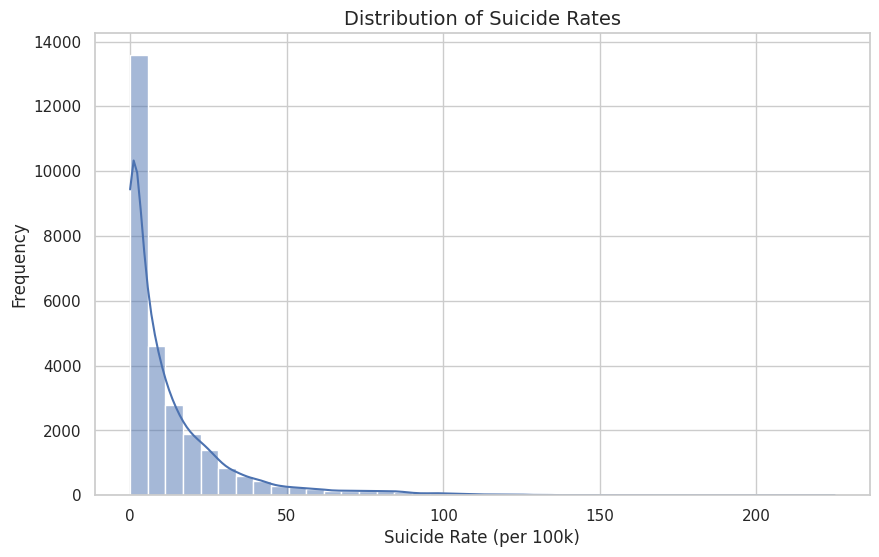

In [24]:
sns.histplot(df['suicides_per_100k'], bins=40, kde=True)

plt.title("Distribution of Suicide Rates")
plt.xlabel("Suicide Rate (per 100k)")
plt.ylabel("Frequency")

Text(0.5, 1.0, 'Boxplot of Suicide Rates')

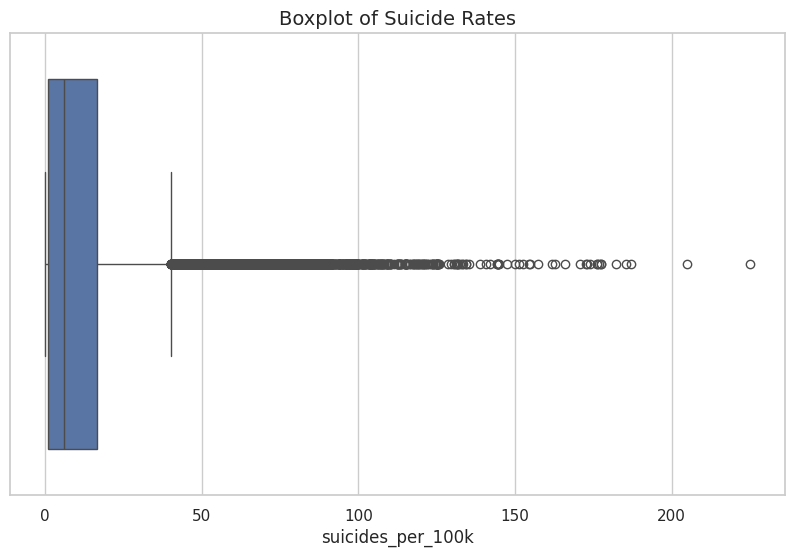

In [25]:
sns.boxplot(x=df['suicides_per_100k'])

plt.title("Boxplot of Suicide Rates")

Text(0.5, 1.0, 'Correlation Heatmap of Suicide Dataset')

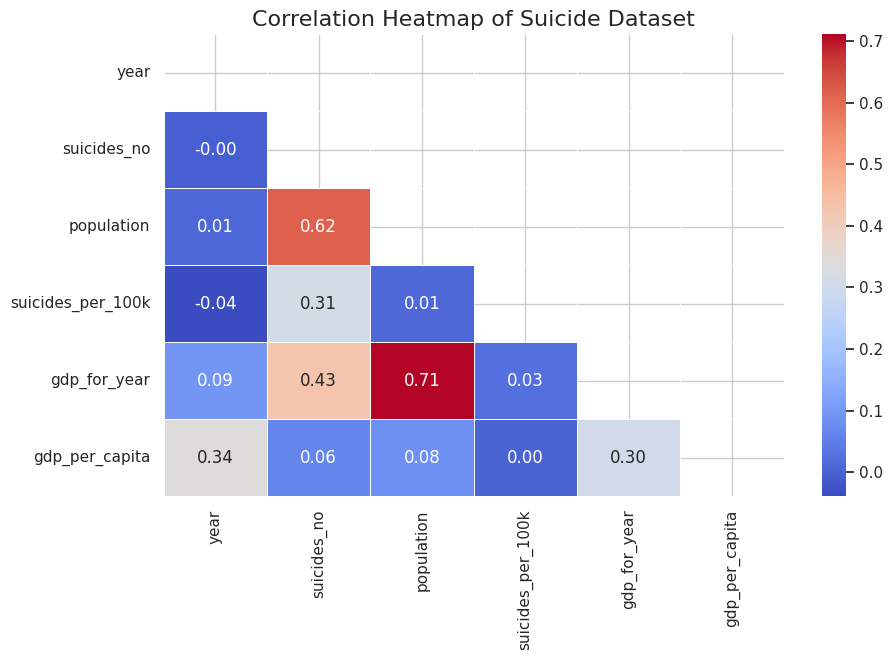

In [26]:
corr_matrix = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle + diagonal
ax = sns.heatmap(
    corr_matrix,
    mask = mask,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

ax.set_title("Correlation Heatmap of Suicide Dataset", fontsize=16)

**The heatmap shows relationships between numerical variables in the dataset.**


*   Population and Suicides_no (0.62): Strong positive correlation. Countries with larger populations tend to have higher total suicide counts.
*   Population and GDP for year (0.71): Strong correlation because countries with larger populations usually have higher total economic output.
*   Suicides_per_100k and population (~0.01): Almost no correlation, indicating that suicide rates are independent of population size.
*   GDP per capita and Suicides_per_100k (~0): Very weak relationship, suggesting economic wealth alone does not strongly influence suicide rates.
*   Year and GDP per capita (0.34): Moderate positive correlation, reflecting gradual economic growth over time.


**Note:** Total suicide counts are strongly influenced by population size, while suicide rates show weak relationships with economic indicators.

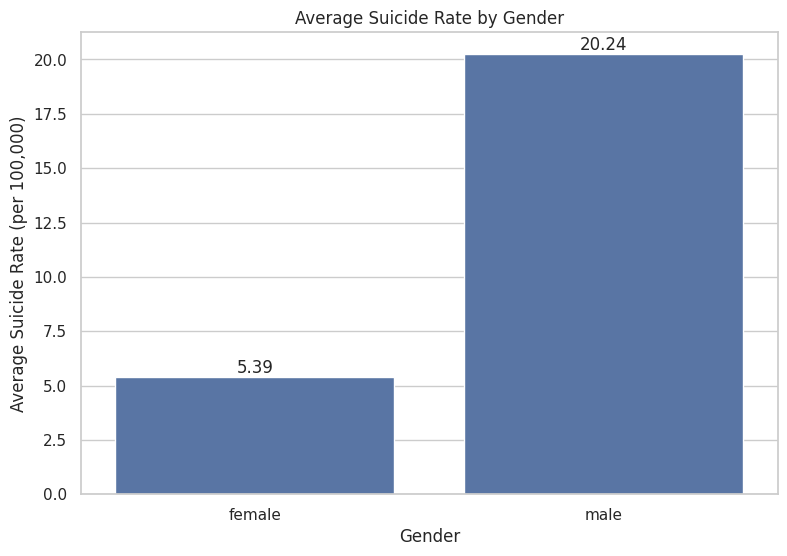

In [27]:
plt.figure(figsize=(9,6))
sns.set_theme(style="whitegrid")

gender = df.groupby('sex')['suicides_per_100k'].mean().reset_index()
ax = sns.barplot(x='sex', y='suicides_per_100k', data=gender)

ax.set_title("Average Suicide Rate by Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Average Suicide Rate (per 100,000)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

The average suicide rate among males is nearly four times higher than females, indicating that gender is a significant factor influencing suicide trends globally.

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, '15-24 years'),
  Text(1, 0, '25-34 years'),
  Text(2, 0, '35-54 years'),
  Text(3, 0, '5-14 years'),
  Text(4, 0, '55-74 years'),
  Text(5, 0, '75+ years')])

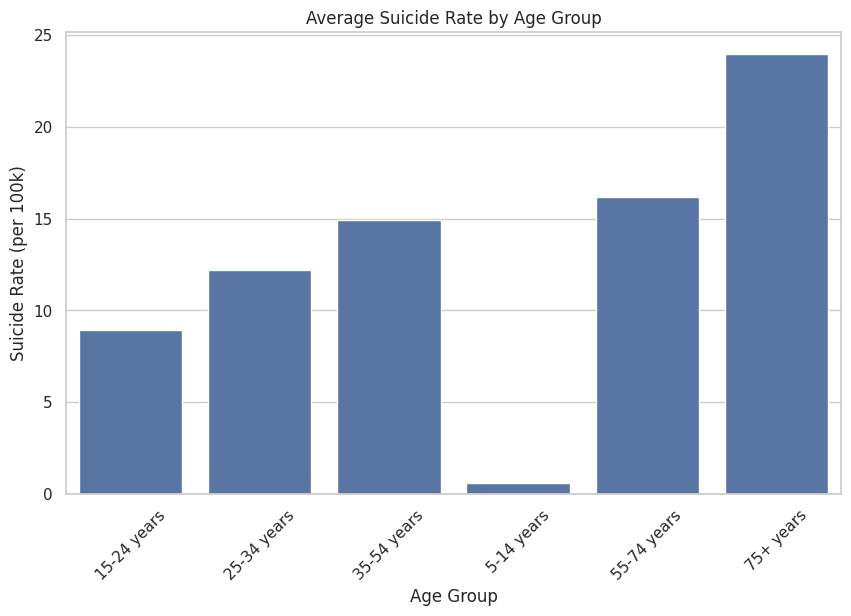

In [28]:
age_data = df.groupby('age')['suicides_per_100k'].mean().reset_index()

sns.barplot(x='age', y='suicides_per_100k', data=age_data)

plt.title("Average Suicide Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Suicide Rate (per 100k)")
plt.xticks(rotation=45)

**Observations include:**

*   Suicide rates increase with age.
*   The 75+ years age group exhibits the highest suicide rate, reaching approximately 24 suicides per 100k population.
*   Middle-aged groups such as 35–54 years and 55–74 years also show relatively high suicide rates.
*   The 5–14 years age group has the lowest suicide rate, remaining below 1 per 100k, indicating that suicide occurrences are extremely rare in children.

<Axes: xlabel='generation', ylabel='age'>

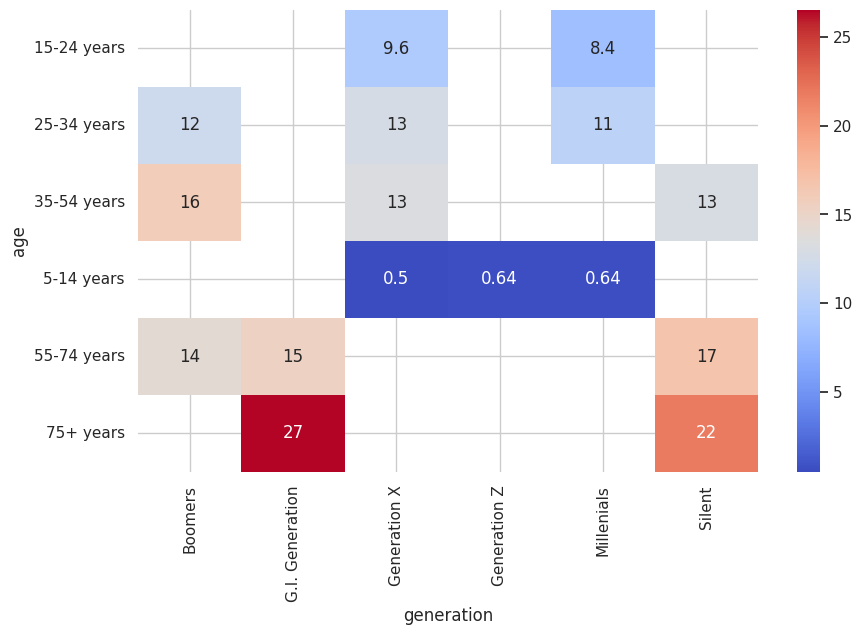

In [29]:
pivot = df.pivot_table(
    values='suicides_per_100k',
    index='age',
    columns='generation',
    aggfunc='mean'
)

sns.heatmap(pivot, annot=True, cmap='coolwarm')

Text(0, 0.5, 'Suicide Rate (per 100K)')

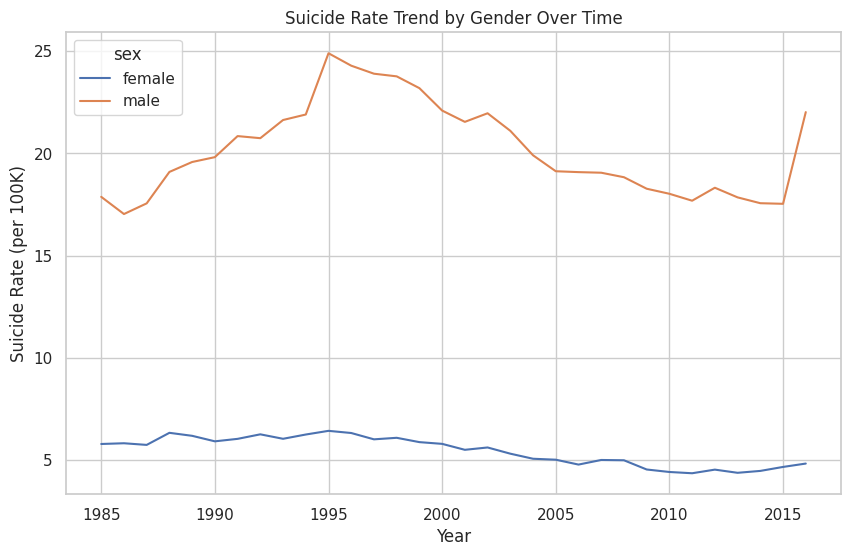

In [30]:
sns.set_theme(style="whitegrid")

year_gender = df.groupby(['year','sex'])[['suicides_per_100k', 'gdp_per_capita']].mean().reset_index()

ax = sns.lineplot(
    x='year',
    y='suicides_per_100k',
    hue='sex',
    data=year_gender
)

ax.set_title("Suicide Rate Trend by Gender Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Suicide Rate (per 100K)")

Text(0.5, 1.0, 'Suicide Rate vs GDP per Capita Over Time')

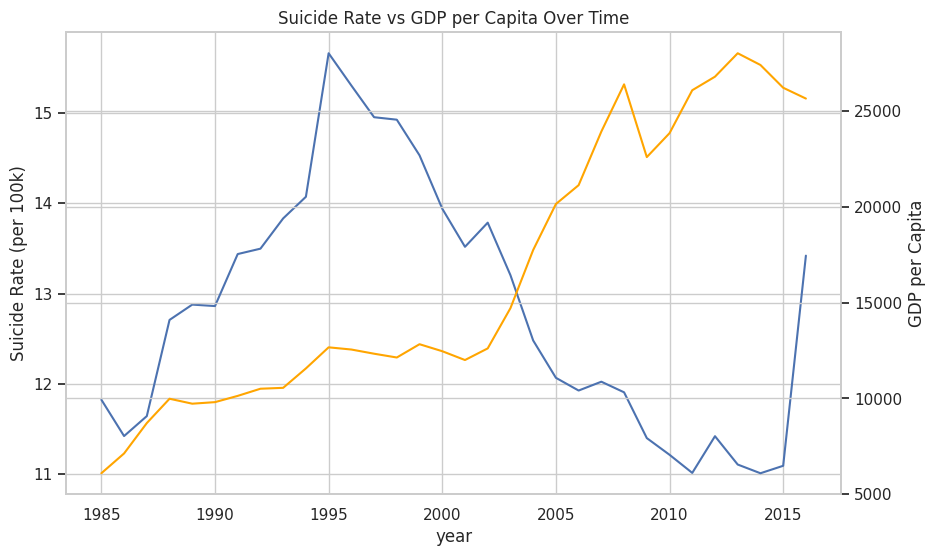

In [31]:
year_data = df.groupby('year')[['suicides_per_100k','gdp_per_capita']].mean().reset_index()

fig, ax1 = plt.subplots()

sns.lineplot(x='year', y='suicides_per_100k', data=year_data, ax=ax1)
ax1.set_ylabel("Suicide Rate (per 100k)")

ax2 = ax1.twinx()
sns.lineplot(x='year', y='gdp_per_capita', data=year_data, color='orange', ax=ax2)
ax2.set_ylabel("GDP per Capita")

ax1.set_title("Suicide Rate vs GDP per Capita Over Time")

Text(0, 0.5, 'Suicide Rate (per 100k)')

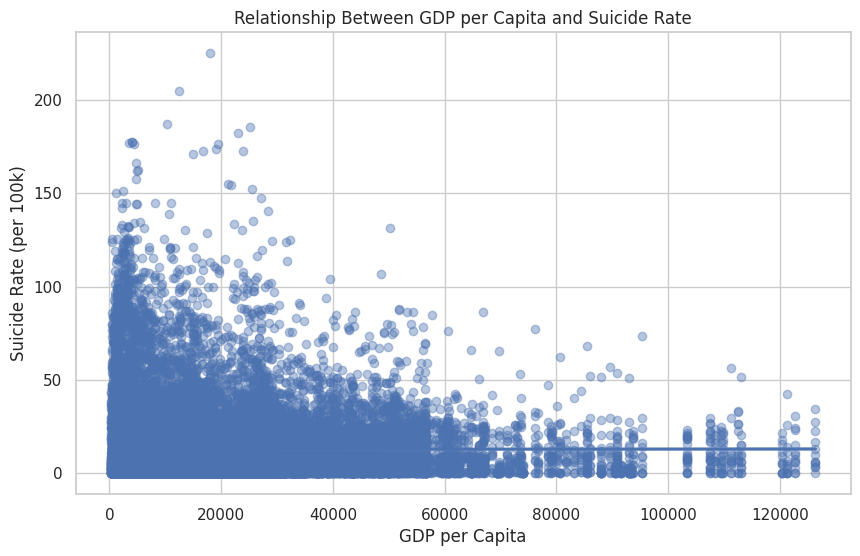

In [32]:
ax = sns.regplot(
    x='gdp_per_capita',
    y='suicides_per_100k',
    data=df,
    scatter_kws={'alpha':0.4}
)

ax.set_title("Relationship Between GDP per Capita and Suicide Rate")
ax.set_xlabel("GDP per Capita")
ax.set_ylabel("Suicide Rate (per 100k)")

Text(0.5, 1.0, 'Top 10 Countries with Highest Suicide Rates')

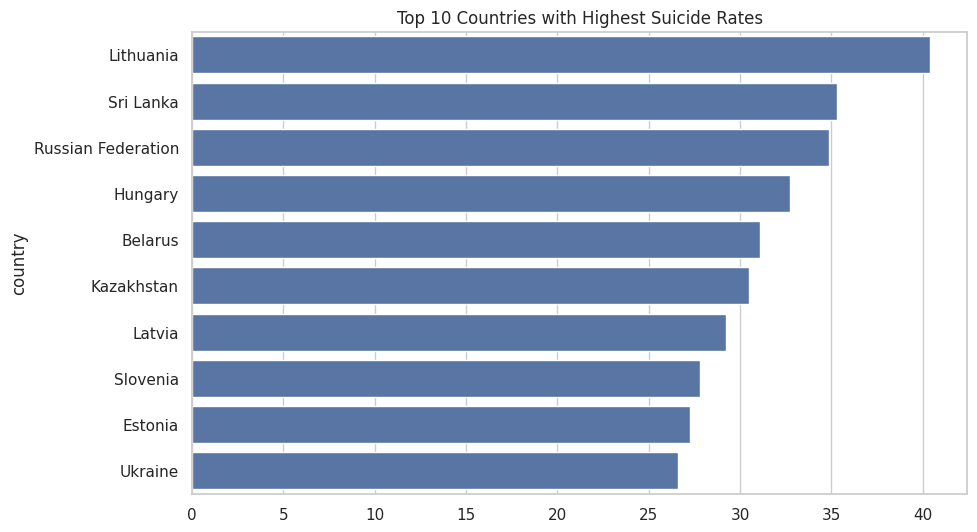

In [33]:
top10 = df.groupby('country')['suicides_per_100k'].mean().sort_values(ascending=False).head(10)

sns.barplot(x=top10.values, y=top10.index)

plt.title("Top 10 Countries with Highest Suicide Rates")

**Observations:**

*   Most countries with the highest suicide rates are located in Eastern Europe and the former Soviet Union, including Lithuania, Russia, Belarus, and Latvia.
*   Sri Lanka also appears among the top countries despite being located in South Asia.
*   High suicide rates in Sri Lanka during the 1990s have been linked to the widespread availability of highly toxic agricultural pesticides, particularly in rural areas.
*   The country also experienced a long civil war (1983–2009), which contributed to social and economic instability.
*   Government restrictions on hazardous pesticides in the 2000s later led to a significant decline in suicide rates.

In [34]:
pivot = df.pivot_table(
    values='suicides_per_100k',
    index='age',
    columns='generation',
    aggfunc='mean'
).fillna(0)

In [35]:
country_rate = df.groupby('country')['suicides_per_100k'].mean().reset_index()

In [36]:
# Regional Influence Analysis on Suicide Trends


# Post-Soviet countries
post_soviet = [
    'Russia','Ukraine','Belarus','Kazakhstan','Lithuania',
    'Latvia','Estonia','Moldova','Armenia','Georgia',
    'Azerbaijan','Uzbekistan','Turkmenistan','Kyrgyzstan','Tajikistan'
]

# Eastern European countries influenced by Soviet bloc
eastern_europe = [
    'Poland','Hungary','Czech Republic','Slovakia',
    'Romania','Bulgaria','Serbia','Croatia','Slovenia',
    'Bosnia and Herzegovina','North Macedonia','Montenegro'
]

In [37]:
# Create filtered datasets

# Remove post-Soviet countries
df_no_soviet = df[~df['country'].isin(post_soviet)]

# Remove post-Soviet + Eastern Europe
exclude_region = post_soviet + eastern_europe
df_no_east = df[~df['country'].isin(exclude_region)]

In [38]:
# Compute yearly suicide trends

global_trend = df.groupby('year')['suicides_per_100k'].mean().reset_index()

non_soviet_trend = df_no_soviet.groupby('year')['suicides_per_100k'].mean().reset_index()

non_east_trend = df_no_east.groupby('year')['suicides_per_100k'].mean().reset_index()

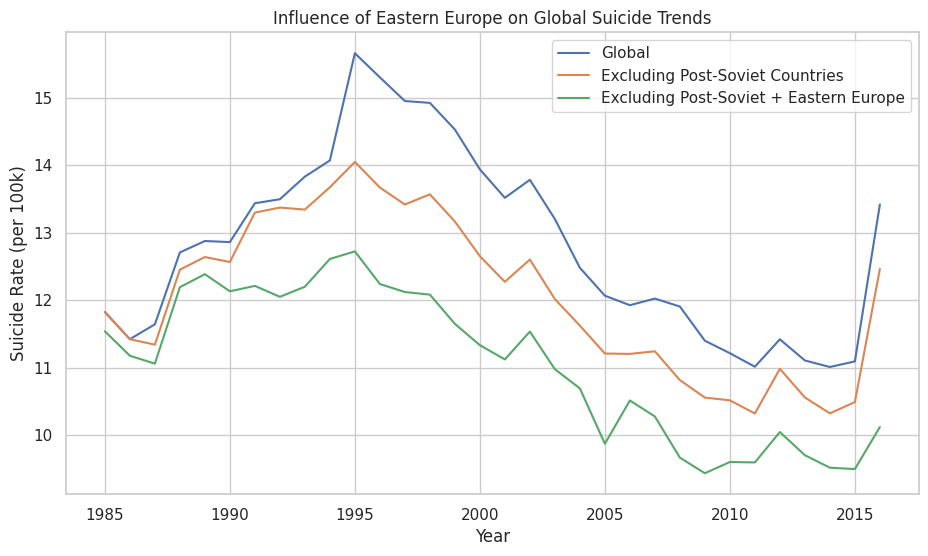

In [39]:
# Plot comparison

plt.figure(figsize=(11,6))

sns.lineplot(x='year', y='suicides_per_100k', data=global_trend, label='Global')

sns.lineplot(x='year', y='suicides_per_100k', data=non_soviet_trend,
             label='Excluding Post-Soviet Countries')

sns.lineplot(x='year', y='suicides_per_100k', data=non_east_trend,
             label='Excluding Post-Soviet + Eastern Europe')

plt.title("Influence of Eastern Europe on Global Suicide Trends")

plt.xlabel("Year")
plt.ylabel("Suicide Rate (per 100k)")

plt.legend()
plt.show()

Overall, this comparison suggests that while global suicide rates followed a broader temporal pattern, the pronounced spike observed during the mid-1990s was substantially amplified by post-Soviet and Eastern European countries, highlighting the significant impact of regional socio-economic transitions on global suicide statistics.

In [40]:
import plotly.express as px

fig = px.choropleth(
    country_rate,
    locations='country',
    locationmode='country names',
    color='suicides_per_100k',
    color_continuous_scale='Reds',
    title='Global Suicide Rates by Country'
)

fig.update_layout(
    width=1200,
    height=700)
fig.show()

**Global Distribution of Suicide Rates:**


*   The choropleth map shows the global distribution of average suicide rates by country. A clear regional pattern appears, with several **Eastern European and post-Soviet countries displaying some of the highest suicide rates worldwide.**
*   Countries such as **Lithuania, Russia, Belarus, Latvia, Estonia**, and **Ukraine** stand out as regions with particularly high suicide rates. This geographic clustering suggests that regional socioeconomic and historical factors may play an important role in shaping suicide patterns.
*   Many of these countries experienced significant **political and economic transitions during the late twentieth century,** especially following the **collapse of the Soviet Union.** These transitions often involved economic instability, social restructuring, and changes in public institutions, which may have influenced long-term mental health outcomes.
*   The analysis also shows that **suicide rates are substantially higher among men than women**, a pattern consistently observed across most countries in the dataset. Previous research suggests that factors such as **societal expectations, economic responsibility, and lower mental health help-seeking among men** may contribute to this disparity.

Overall, the geographic patterns indicate that suicide rates are influenced by a **complex combination of social, economic, cultural, and historical factors**, rather than a single cause.

## Statistical Significance Testing ⬇

In [41]:
# -----------------------------------
# Descriptive Statistics
# -----------------------------------

mean_rate = df['suicides_per_100k'].mean()
mad_rate = np.mean(np.abs(df['suicides_per_100k'] - mean_rate))
variance_rate = df['suicides_per_100k'].var()
std_rate = df['suicides_per_100k'].std()

print(f"Mean Suicide Rate: {mean_rate:.2f}")
print(f"Mean Absolute Deviation: {mad_rate:.2f}")
print(f"Variance: {variance_rate:.2f}")
print(f"Standard Deviation: {std_rate:.2f}")

Mean Suicide Rate: 12.82
Mean Absolute Deviation: 12.57
Variance: 359.54
Standard Deviation: 18.96


In [51]:
import numpy as np
from scipy.stats import f_oneway

def eta_squared(groups):
    """Calculates the effect size for a one-way ANOVA."""
    all_data = np.concatenate(groups)
    grand_mean = np.mean(all_data)

    # Sum of Squares Total
    sst = np.sum((all_data - grand_mean)**2)

    # Sum of Squares Between groups
    ssb = sum(len(g) * (np.mean(g) - grand_mean)**2 for g in groups)

    return ssb / sst if sst != 0 else 0

def anova_test(df, column):
    # Create list of arrays for each group
    groups = [group['suicides_per_100k'].values
              for name, group in df.groupby(column)]

    # Perform ANOVA
    f, p = f_oneway(*groups)

    # Calculate Effect Size
    eta = eta_squared(groups)

    print(f"{column:10} ANOVA -> F: {f:<6.2f} P: {p:<6.3f} Eta²: {eta:.3f}")

In [53]:
anova_test(df, 'sex')
anova_test(df, 'age')
anova_test(df, 'generation')

sex        ANOVA -> F: 5035.43 P: 0.000  Eta²: 0.153
age        ANOVA -> F: 909.79 P: 0.000  Eta²: 0.141
generation ANOVA -> F: 709.66 P: 0.000  Eta²: 0.113


**ANOVA Interpretation**

*   The ANOVA results indicate statistically significant differences in suicide
rates across **gender, age groups, and generations** (p < 0.05).

*   The analysis shows that **gender has a significant influence on suicide patterns**, with males exhibiting substantially higher suicide rates than females. The **age group analysis produced a very large F-statistic**, indicating that suicide rates vary considerably across different age categories. This suggests that suicide risk changes significantly across different stages of life.

*   Similarly, the ANOVA test across **generational cohorts** shows significant differences, indicating that suicide patterns vary across historical generations.

Overall, these findings confirm that **demographic factors such as gender, age, and generation play a significant role in shaping suicide rates across populations**.